In [3]:
# find the gpu devices
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

# in order import from parent directory
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [4]:
import torch
from types import SimpleNamespace
import matplotlib.pyplot as plt
import csv
import ast
from custom_vision_transformer import custom_vit_s_16
from model_training_code.training_utils import get_data_loaders, val_one_epoch
from model_analysis_code.utils import convert_qkv_to_q_k_v

In [8]:
params = SimpleNamespace(
    gpu_idx=1,
    num_classes=100,
    img_size=224,
    batch_size=128,
    checkpoint_path="../training_checkpoints/checkpoint1/vit_custom_epoch_200.pth",
    use_bias=True,
    bias_only=None,
    bias_topk=None,
    bias_score_threshold=None,
)

In [9]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 2
Device: cuda:1 NVIDIA RTX A4500


In [10]:
model = custom_vit_s_16(num_classes=params.num_classes, image_size=params.img_size, use_bias=params.use_bias, bias_only=params.bias_only, bias_topk=params.bias_topk, bias_score_threshold=params.bias_score_threshold).to(device)
checkpoint = torch.load(params.checkpoint_path, map_location=device)
checkpoint = checkpoint["model_state_dict"]
checkpoint = convert_qkv_to_q_k_v(checkpoint)
model.load_state_dict(checkpoint)
model.eval();

In [11]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

In [12]:
avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
print(f"Validation Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

Validation Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


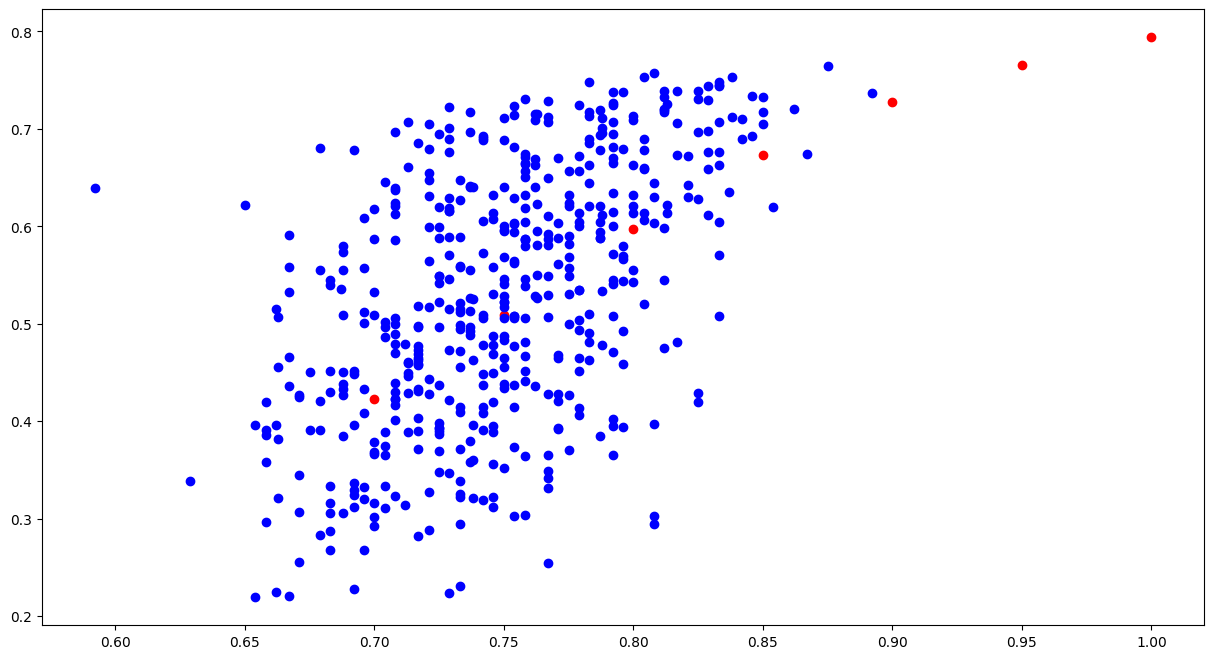

In [14]:
method = "bias_score_threshold"

default_values = [[1.0]*12, [0.95]*12, [0.9]*12, [0.85]*12, [0.8]*12, [0.75]*12, [0.7]*12, [0.65]*12, [0.6]*12, [0.55]*12, [0.5]*12, [0.45]*12, [0.4]*12, [0.35]*12, [0.3]*12, [0.25]*12, [0.2]*12, [0.15]*12, [0.1]*12, [0.05]*12, [0.0]*12]

plt.figure(figsize=(15, 8))

with open(f"../results/pruning_graphs/{method}.csv", mode='r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        threshold_list = ast.literal_eval(row["threshold"])
        threshold_list = [float(e) for e in threshold_list]
        if threshold_list in default_values:
            color = 'red'
        else:
            color = 'blue'
        plt.scatter(float(row["threshold_mean"]), float(row["accuracy"]), label=f"Threshold: {row['threshold_mean']}", c=color)

plt.show()

Bias Only: [False, False, False, False, False, False, False, False, False, False, False, False], Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, False, False, False, False, False, False, True, True], Accuracy: 0.7880, Top-5 Accuracy: 0.9266, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, False, False, False, False, True, True, True, True], Accuracy: 0.7716, Top-5 Accuracy: 0.9162, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, False, False, True, True, True, True, True, True], Accuracy: 0.7474, Top-5 Accuracy: 0.8996, Average Pruning Ratio: 0.0000


Bias Only: [False, False, False, False, True, True, True, True, True, True, True, True], Accuracy: 0.6444, Top-5 Accuracy: 0.8408, Average Pruning Ratio: 0.0000


Bias Only: [False, False, True, True, True, True, True, True, True, True, True, True], Accuracy: 0.3096, Top-5 Accuracy: 0.5554, Average Pruning Ratio: 0.0000


Bias Only: [True, True, True, True, True, True, True, True, True, True, True, True], Accuracy: 0.1634, Top-5 Accuracy: 0.3714, Average Pruning Ratio: 0.0000


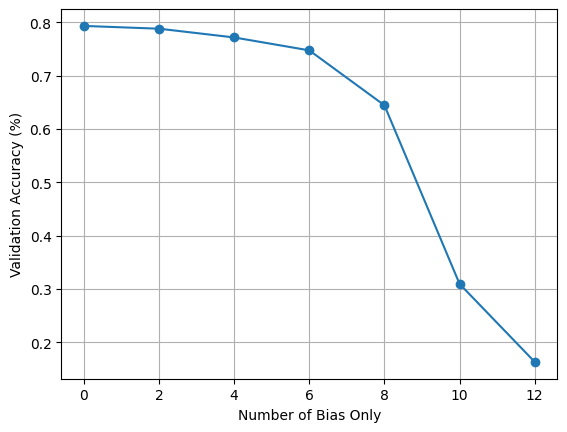

In [15]:
# plot accuracy en fonction du nombre de bias_only

bias_only_values = [[False]*12, [False]*10 + [True]*2, [False]*8 + [True]*4, [False]*6 + [True]*6, [False]*4 + [True]*8, [False]*2 + [True]*10, [True]*12]
acc_values = []
avg_pruned_ratio_values = []

for bias_only in bias_only_values:
    model = custom_vit_s_16(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_only=bias_only, bias_topk=None, bias_score_threshold=None).to(device)
    checkpoint = torch.load(params.checkpoint_path, map_location=device)
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval(); 

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    avg_pruned_ratio_values.append(avg_pruned_ratio)
    print(f"Bias Only: {bias_only}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.plot([sum(bias_only) for bias_only in bias_only_values], acc_values, marker='o')
plt.xlabel("Number of Bias Only")
plt.ylabel("Validation Accuracy (%)")
plt.xticks([sum(bias_only) for bias_only in bias_only_values])
plt.grid()
plt.show()